# Dog Image Classification using GPT-5

We will use GPT-5 to classify the dog images we used in week 3 when discussing the image classification using ResNet.

You need to verify your identification to use GTP-5 model

{'breed': 'Long-Haired Chihuahua', 'confidence': 0.95, 'rationale': 'Small size, long coat, large ears, and characteristic Chihuahua features.'}


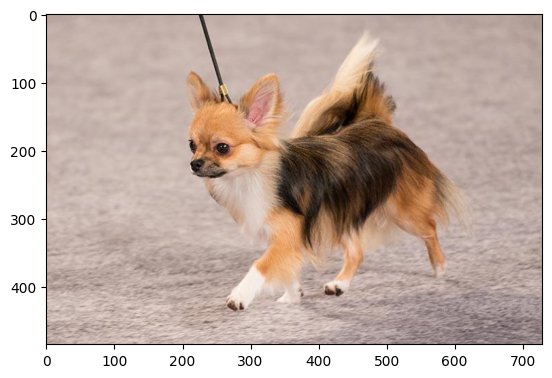

In [4]:
from openai import OpenAI
import os
import base64, mimetypes, pathlib
from dotenv import load_dotenv
import openai
from PIL import Image
import matplotlib.pyplot as plt

# define the environment path. it is at the parent folder
env_path ="../.env"

load_dotenv(dotenv_path=env_path, override=True)

api_key = os.getenv("OPENAI_API_KEY")

client = OpenAI()

def encode_local_image(path: str) -> str:
    p = pathlib.Path(path)
    mime = mimetypes.guess_type(p)[0] or "image/png"
    b64 = base64.b64encode(p.read_bytes()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

image_source = {"type": "image_url", "image_url": {"url": encode_local_image("images/chihuahua.jpg")}}

system = {
    "role": "system",
    "content": "You are an image classification expert. Respond ONLY with valid JSON."
}

user = {
    "role": "user",
    "content": [
        {"type": "text",
         "text": (
             "Classify the image by identifying the breed of the dog. "
             "Also provide a confidence (0-1) and a brief rationale (<= 15 words)."
         )},
        image_source
    ]
}

resp = client.chat.completions.create(
    model="gpt-5-chat-latest",   # vision-capable model
    messages=[system, user],
    temperature=0,
    response_format={"type": "json_object"}   # structured output
)

import json
result = json.loads(resp.choices[0].message.content)

print(result)

# Display image
img = Image.open("images/chihuahua.jpg")
plt.imshow(img)

# Classify the six dog images we used in week 3

<p style="color:green; font-weight:bold;">GPT 5 classify all dogs correctly!</p>

In [5]:
import base64, mimetypes, pathlib, json, time
from pathlib import Path
import pandas as pd
from openai import OpenAI
import os
from dotenv import load_dotenv

# define the environment path. it is at the parent folder

env_path ="../.env"

load_dotenv(dotenv_path=env_path, override=True)

api_key = os.getenv("OPENAI_API_KEY")

# ---------- Setup ----------
client = OpenAI() 
MODEL = "gpt-5-chat-latest"  # vision-capable model
IMAGE_DIR = Path("images")    # folder containing your images
OUT_CSV = "data/dog_breed_classification.csv"

# Which file extensions to include
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif"}

def encode_local_image(path: Path) -> str:
    mime = mimetypes.guess_type(str(path))[0] or "image/png"
    b64 = base64.b64encode(path.read_bytes()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

def classify_image(path: Path) -> dict:
    """Returns dict with filename, breed, confidence, rationale (strings/numbers)."""
    data_url = encode_local_image(path)
    image_source = {"type": "image_url", "image_url": {"url": data_url}}

    system = {
        "role": "system",
        "content": "You are an image classification expert. Respond ONLY with valid JSON."
    }
    user = {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": (
                    "Classify the image by identifying the breed of the dog. "
                    "Also provide a confidence (0-1) and a brief rationale (<= 15 words). "
                    "Return JSON with keys: breed, confidence, rationale."
                ),
            },
            image_source,
        ],
    }

    try:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=[system, user],
            temperature=0,
            response_format={"type": "json_object"},
        )
        payload = json.loads(resp.choices[0].message.content)

        # Normalize/validate fields
        breed = str(payload.get("breed", "")).strip()
        confidence = payload.get("confidence", None)
        try:
            confidence = float(confidence) if confidence is not None else None
        except Exception:
            confidence = None
        rationale = str(payload.get("rationale", "")).strip()

        return {
            "filename": path.name,
            "breed": breed,
            "confidence": confidence,
            "rationale": rationale,
        }

    except Exception as e:
        # Return a row with error info instead of failing the whole batch
        return {
            "filename": path.name,
            "breed": "",
            "confidence": None,
            "rationale": f"ERROR: {e}",
        }

# ---------- Batch process ----------
rows = []
for img_path in sorted(IMAGE_DIR.iterdir()):
    if img_path.suffix.lower() in IMAGE_EXTS and img_path.is_file():
        rows.append(classify_image(img_path))
        # (Optional) polite pacing for rate limits
        time.sleep(0.2)

df = pd.DataFrame(rows, columns=["filename", "breed", "confidence", "rationale"])
print(df)

# Save to CSV
df.to_csv(OUT_CSV, index=False)

print(f"Saved results to {OUT_CSV}")

                 filename                  breed  confidence  \
0        bull_terrier.jpg           Bull Terrier        0.98   
1           chihuahua.jpg  Long-Haired Chihuahua        0.95   
2     german_shepherd.jpg        German Shepherd        0.98   
3    golden_retriever.jpg       Golden Retriever        0.97   
4               husky.jpg         Siberian Husky        0.98   
5  labrador_retriever.jpg     Labrador Retriever        0.97   

                                           rationale  
0  Distinctive egg-shaped head and muscular body ...  
1  Small size, long coat, large ears, and curled ...  
2  Distinct black and tan coat, erect ears, stron...  
3  Golden coat, medium-large build, friendly expr...  
4  Blue eyes, erect ears, thick coat, and wolf-li...  
5  Yellow coat, broad head, friendly expression, ...  
Saved results to data/dog_breed_classification.csv


# Practice on Your Own

Use GPT-5 to classify the same images you used in your Week 3 assignment. Compare its predictions with those from the ResNet model, did GPT-5 achieve better results?